<a href="https://colab.research.google.com/github/KaisuH/Emotion-AI/blob/main/Emotion_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Emotion AI

## Nutshell
As of now this project is under development.

This program classifies emotions from images of human faces. The dataset consists of over 20000 facial images that have been labeled with facial expression/emotion and approximately 2000 images with their keypoint annotations.

The program will train two models which will detect
1.   facial keypoints
2.   detect emotions.

Then these models are combined into one model that will provide a holistic prediction of the emotion as the output.

In [3]:
# Mount the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd '/content/drive/MyDrive/Colab Notebooks/Emotion-AI/'


/content/drive/MyDrive/Colab Notebooks/Emotion-AI


## Part 1. Key facial points detection

In this section I create a DL model with convolutional neural network and residual blocks to predict facial keypoints.
The data set is from https://www.kaggle.com/c/facial-keypoints-detection/overview.
The dataset consists of input images with 15 facial key points each.
The training.csv file has 7049 face images with corresponding keypoint locations. The test.csv file has face images only, and will be used to test the model.

### Importing libraries

In [ ]:
# Import the necessary packages
import pandas as pd
import numpy as np
import os
import PIL
import seaborn as sns
import pickle
from PIL import *
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from IPython.display import display
from tensorflow.python.keras import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import *
from tensorflow.keras import backend as K
from keras import optimizers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

### Load data

Here I load the dataset for training the model. The data consists of 31 columns: 2 columns for each of the 15 keypoints (x- and y-coordinates) and one image.

In [ ]:
# load facial key points data
key_points_df = pd.read_csv('Data/data.csv')

In [ ]:
key_points_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2140 entries, 0 to 2139
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   left_eye_center_x          2140 non-null   float64
 1   left_eye_center_y          2140 non-null   float64
 2   right_eye_center_x         2140 non-null   float64
 3   right_eye_center_y         2140 non-null   float64
 4   left_eye_inner_corner_x    2140 non-null   float64
 5   left_eye_inner_corner_y    2140 non-null   float64
 6   left_eye_outer_corner_x    2140 non-null   float64
 7   left_eye_outer_corner_y    2140 non-null   float64
 8   right_eye_inner_corner_x   2140 non-null   float64
 9   right_eye_inner_corner_y   2140 non-null   float64
 10  right_eye_outer_corner_x   2140 non-null   float64
 11  right_eye_outer_corner_y   2140 non-null   float64
 12  left_eyebrow_inner_end_x   2140 non-null   float64
 13  left_eyebrow_inner_end_y   2140 non-null   float

In [ ]:
# Are there null values?

key_points_df.isnull().sum()

,0
left_eye_center_x,0
left_eye_center_y,0
right_eye_center_x,0
right_eye_center_y,0
left_eye_inner_corner_x,0
left_eye_inner_corner_y,0
left_eye_outer_corner_x,0
left_eye_outer_corner_y,0
right_eye_inner_corner_x,0
right_eye_inner_corner_y,0


The image data is an object that contains numbers as a string in the shape of (2140,). That has to be transformed into the real shape of the images (96, 96). Thus we create a 1-D array of the string and reshape it to 2D array.

In [ ]:
key_points_df['Image'].shape
key_points_df['Image'][0]
type(key_points_df['Image'][0])

str

In [ ]:
key_points_df['Image'] = key_points_df['Image']. apply(lambda img: np.fromstring(img, dtype = int, sep = ' ').reshape(96,96))


In [ ]:
key_points_df['Image'][0].shape

(96, 96)

In [ ]:
key_points_df.describe()

,left_eye_center_x,left_eye_center_y,right_eye_center_x,right_eye_center_y,left_eye_inner_corner_x,left_eye_inner_corner_y,left_eye_outer_corner_x,left_eye_outer_corner_y,right_eye_inner_corner_x,right_eye_inner_corner_y,...,nose_tip_x,nose_tip_y,mouth_left_corner_x,mouth_left_corner_y,mouth_right_corner_x,mouth_right_corner_y,mouth_center_top_lip_x,mouth_center_top_lip_y,mouth_center_bottom_lip_x,mouth_center_bottom_lip_y
count,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,...,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000,2140.000000
mean,66.221549,36.842274,29.640269,37.063815,59.272128,37.856014,73.412473,37.640110,36.603107,37.920852,...,47.952141,57.253926,63.419076,75.887660,32.967365,76.134065,48.081325,72.681125,48.149654,82.630412
std,2.087683,2.294027,2.051575,2.234334,2.005631,2.034500,2.701639,2.684162,1.822784,2.009505,...,3.276053,4.528635,3.650131,4.438565,3.595103,4.259514,2.723274,5.108675,3.032389,4.813557
min,47.835757,23.832996,18.922611,24.773072,41.779381,27.190098,52.947144,26.250023,24.112624,26.250023,...,24.472590,41.558400,43.869480,57.023258,9.778137,56.690208,32.260312,56.719043,33.047605,57.232296
25%,65.046300,35.468842,28.472224,35.818377,58.113054,36.607950,71.741978,36.102409,35.495730,36.766783,...,46.495330,54.466000,61.341291,72.874263,30.879288,73.280038,46.580004,69.271669,46.492000,79.417480
50%,66.129065,36.913319,29.655440,37.048085,59.327154,37.845220,73.240045,37.624207,36.620735,37.920336,...,47.900511,57.638582,63.199057,75.682465,33.034022,75.941985,47.939031,72.395978,47.980854,82.388899
75%,67.332093,38.286438,30.858673,38.333884,60.521492,39.195431,74.978684,39.308331,37.665280,39.143921,...,49.260657,60.303524,65.302398,78.774969,35.063575,78.884031,49.290000,75.840286,49.551936,85.697976
max,78.013082,46.132421,42.495172,45.980981,69.023030,47.190316,87.032252,49.653825,47.293746,44.887301,...,65.279654,75.992731,84.767123,94.673637,50.973348,93.443176,61.804506,93.916338,62.438095,95.808983


In [ ]:
# A sample of the image data
i=6
col_num=len(key_points_df.columns)
type(key_points_df['left_eye_center_y'][0])

numpy.float64

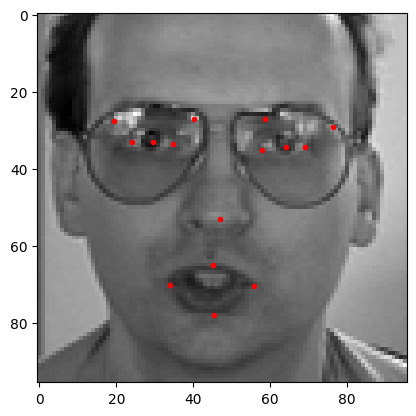

In [ ]:
plt.imshow(key_points_df['Image'][i],cmap='grey')
#generate a sequence of numbers starting from 1, going up to (but not including) 31, increasing by two at each step
for j in range(1,col_num,2):
  #Use .iloc for positional indexing
  plt.plot(key_points_df.iloc[i,j-1],key_points_df.iloc[i,j],marker='.', color='r')

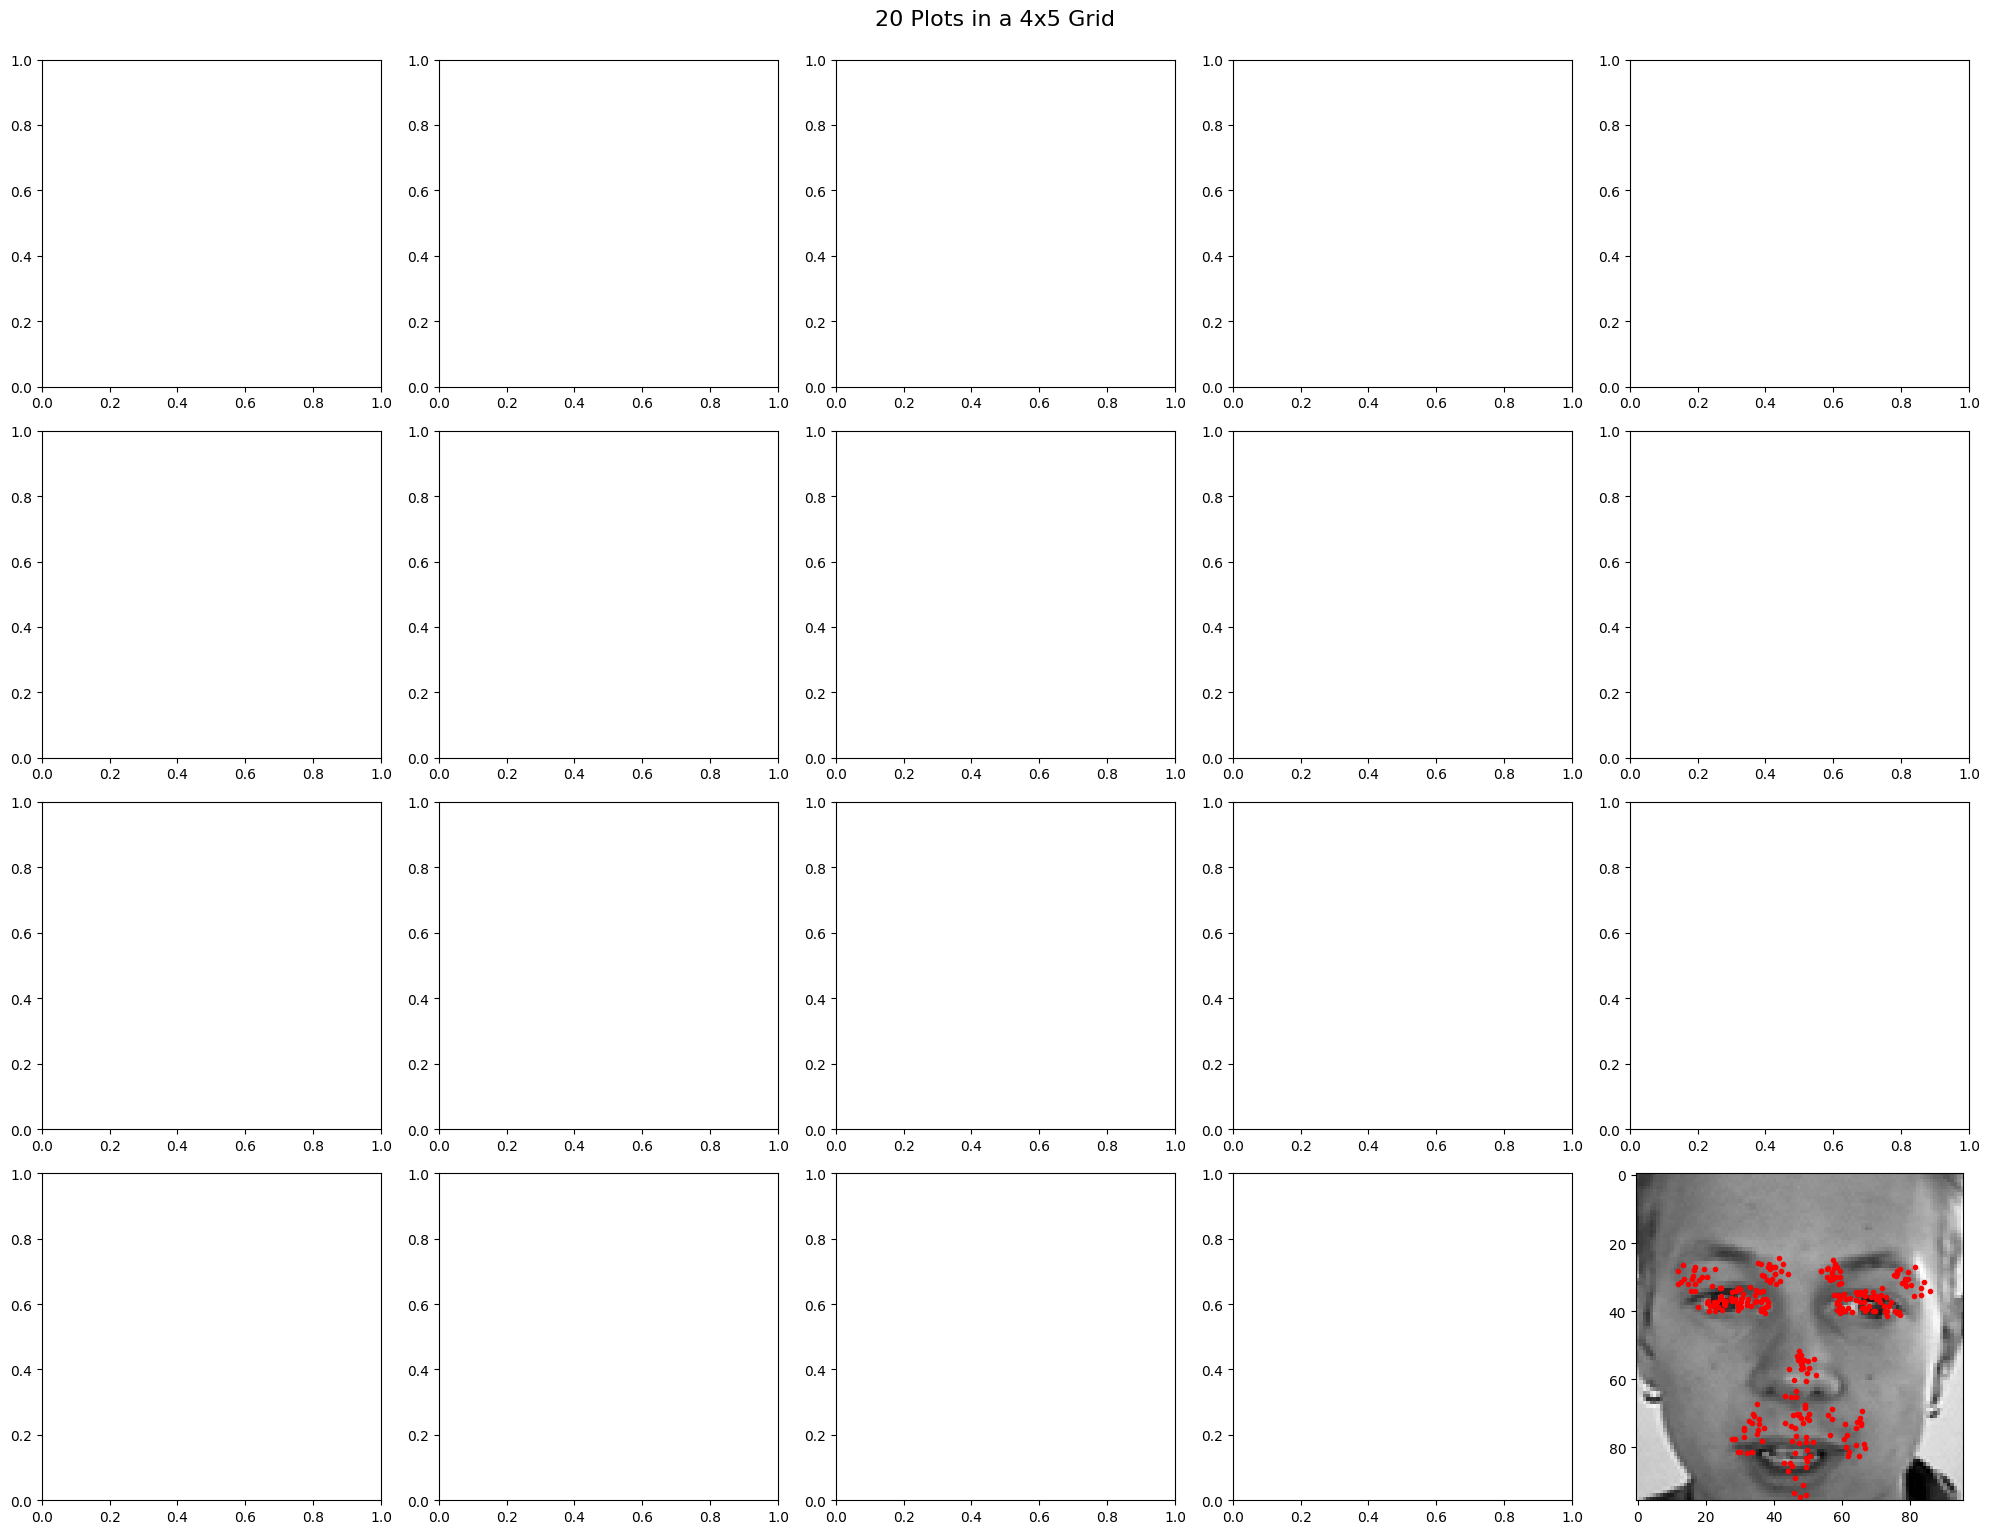

In [ ]:
# Looking at a few more images

#fig = plt.figure(figsize=(10,10))
# Create a 4x5 grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(20, 15))  # Adjust figsize as needed
# Flatten the axes array for easy iteration
axes = axes.flatten()
for i in range(20):
  ax = axes[i]
  plt.imshow(key_points_df['Image'][i],cmap='grey')
  #generate a sequence of numbers starting from 1, going up to (but not including) 31, increasing by two at each step
  for j in range(1,col_num,2):
    #Use .iloc for positional indexing
    plt.plot(key_points_df.iloc[i,j-1],key_points_df.iloc[i,j],marker='.', color='r')

# If there are any unused subplots, hide them
for j in range(20, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout to prevent overlap
plt.tight_layout()

# Optional: Add a main title for the entire figure
fig.suptitle('20 Plots in a 4x5 Grid', fontsize=16, y=1.02)  # y parameter adjusts the title position

# Display the plots
plt.show()


# Git commands
Storage for git commands

In [ ]:
# Run this after saving
# Git config
!git config --global user.name "KaisuH"
!git config --global user.email "kaisuhh@gmail.com"

In [ ]:
# Add changes
!git add .

In [ ]:
# Commit changes and remember to change commit message
!git commit -m "Added plots"

[main 3e77603] Added plots
 19 files changed, 191081 insertions(+), 1 deletion(-)
 rename .gitignore => .gitignore.txt (100%)
 create mode 100644 Data/Emotion+AI+Dataset.zip
 create mode 100644 Data/augmented.csv
 create mode 100644 Data/data.csv
 create mode 100644 Data/detection.json
 create mode 100644 Data/emotion.json
 create mode 100644 Data/face_detection.json
 create mode 100644 Data/facial_detection.ipynb
 create mode 100644 Data/icml_face_data.csv
 create mode 100644 Data/models.config
 create mode 100644 Data/server.log
 create mode 100644 Data/test.csv
 create mode 100644 Data/training.csv
 create mode 100644 Data/weights.h5
 create mode 100644 Data/weights.hdf5
 create mode 100644 Data/weights_emotion.hdf5
 create mode 100644 Data/weights_emotions.hdf5
 create mode 100644 Data/weights_keypoint.hdf5
 rewrite Emotion_AI.ipynb (94%)


Unstaged changes after reset:
D	.gitignore
M	Emotion_AI.ipynb


In [ ]:
# Push changes
with open('/content/drive/MyDrive/tokens/token1.txt', 'r') as f:
    token = f.read().strip()

!git push https://$token@github.com/KaisuH/Emotion-AI.git

Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 4.39 KiB | 280.00 KiB/s, done.
Total 3 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/KaisuH/Emotion-AI.git
   36a209d..de16dcf  main -> main
